In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [29]:
dataset=pd.read_csv("Advertising.csv")

x=dataset[["TV","Radio","Newspaper"]].values
y=dataset["Sales"]

print(x.shape)

(200, 3)


x_mean: [147.0425  23.264   30.554 ]
x_std: [85.63933176 14.80964564 21.72410606]
w: [ 3.91925365  2.79206274 -0.02253861]
b: 14.0225


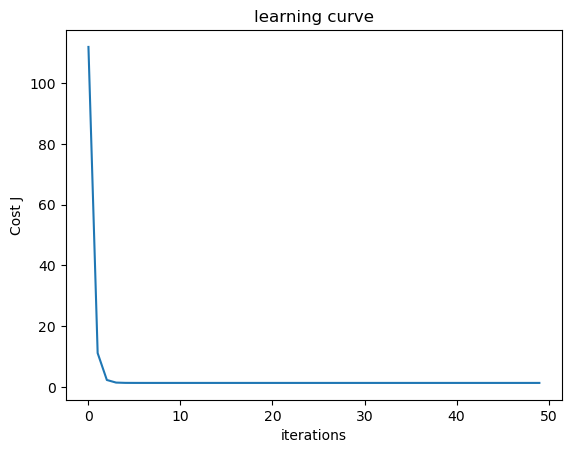

In [30]:
x_mean=x.mean(axis=0)
x_std=x.std(axis=0)
x=(x-x_mean)/x_std
m=x.shape[0]
w=np.zeros(x.shape[1])
b=0

num_iter=50
alpha=0.7

J_wb=[]

for i in range(num_iter):
    y_hat=np.dot(x,w)+b
    error=y_hat-y

    gradient_w=(1/m)*np.dot(error,x)
    gradient_b=(1/m)*error.sum()

    w=w-alpha*gradient_w
    b=b-alpha*gradient_b

    J=(1/(2*m))*(error**2).sum()
    J_wb.append(J)


print(f"x_mean: {x_mean}")
print(f"x_std: {x_std}")
print(f"w: {w}\nb: {b}")

iterations=np.arange(num_iter)

plt.figure()
plt.plot(iterations,J_wb)
plt.title("learning curve")
plt.xlabel("iterations")
plt.ylabel("Cost J")
plt.show()

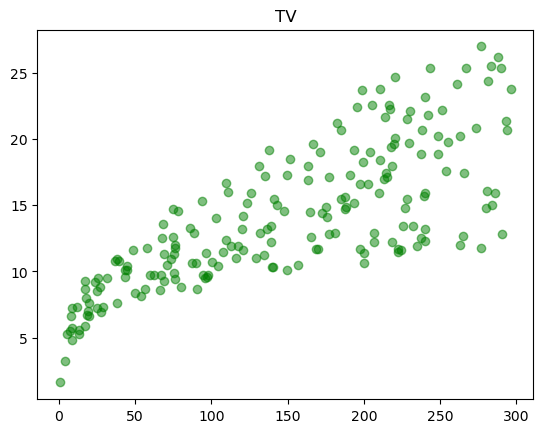

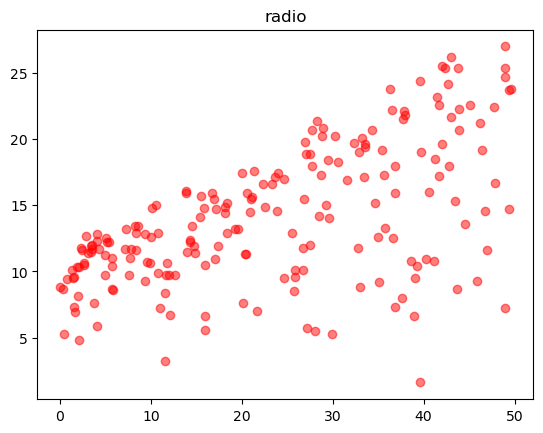

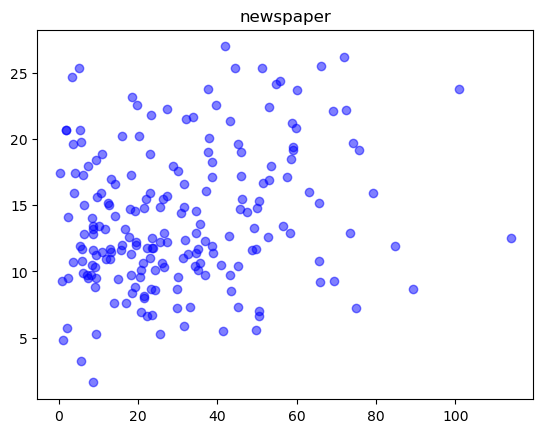

In [35]:
plt.figure()
plt.plot(dataset["TV"],y,color="green",linestyle="none",marker="o",alpha=0.5)
plt.title("TV")
plt.show()

plt.figure()
plt.plot(dataset["Radio"],y,color="red",linestyle="none",marker="o",alpha=0.5)
plt.title("radio")
plt.show()

plt.figure()
plt.plot(dataset["Newspaper"],y,color="blue",linestyle="none",marker="o",alpha=0.5)
plt.title("newspaper")
plt.show()

In [33]:
tv=float(input("ads through tv: "))
radio=float(input("ads through radio: "))
newspaper=float(input("ads in newspaper: "))

test_case=np.array([tv,radio,newspaper])

test_case=(test_case-test_case.mean(axis=0))/test_case.std(axis=0)

prediction=np.dot(test_case,w)+b

print(f"for the given number of ads the net sale would be approx: ${prediction:.2f} K")

ads through tv:  17.2
ads through radio:  45.9
ads in newspaper:  69.3


for the given number of ads the net sale would be approx: $9.27 K
